In [1]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/insurance_data.csv")

# Hypothesis Test: Gender vs Claim Amount

## Null Hypothesis (H0)
There is no significant difference in claim amounts between genders.

## Alternative Hypothesis (H1)
There is a significant difference in claim amounts between genders.

In [3]:
male_claims = df[df["Gender"] == "Male"]["TotalClaims"]

female_claims = df[df["Gender"] == "Female"]["TotalClaims"]

In [4]:
t_stat, p_value = stats.ttest_ind(
    male_claims,
    female_claims,
    equal_var=False
)

print("T-statistic:", t_stat)

print("P-value:", p_value)

T-statistic: -0.054709164724640366
P-value: 0.956371266680949


## Interpretation

If the p-value is less than 0.05:
- Reject the null hypothesis.

Otherwise:
- Fail to reject the null hypothesis.

# Hypothesis Test: Province vs Claim Amount

## Null Hypothesis (H0)
There is no significant difference in claim amounts across provinces.

## Alternative Hypothesis (H1)
There is a significant difference in claim amounts across provinces.

In [5]:
province_groups = [
    group["TotalClaims"].values
    for name, group in df.groupby("Province")
]

In [6]:
f_stat, p_value = stats.f_oneway(*province_groups)

print("F-statistic:", f_stat)

print("P-value:", p_value)

F-statistic: 1.6340049622600488
P-value: 0.16262721551134246


## Interpretation

If p-value < 0.05:
- Reject the null hypothesis.
- Province significantly affects claim amounts.

Otherwise:
- Fail to reject the null hypothesis.

# Hypothesis Test: Vehicle Type vs Claim Amount

In [7]:
vehicle_groups = [
    group["TotalClaims"].values
    for name, group in df.groupby("VehicleType")
]

In [8]:
f_stat, p_value = stats.f_oneway(*vehicle_groups)

print("F-statistic:", f_stat)

print("P-value:", p_value)

F-statistic: 144.69407125795462
P-value: 8.750370546863522e-92


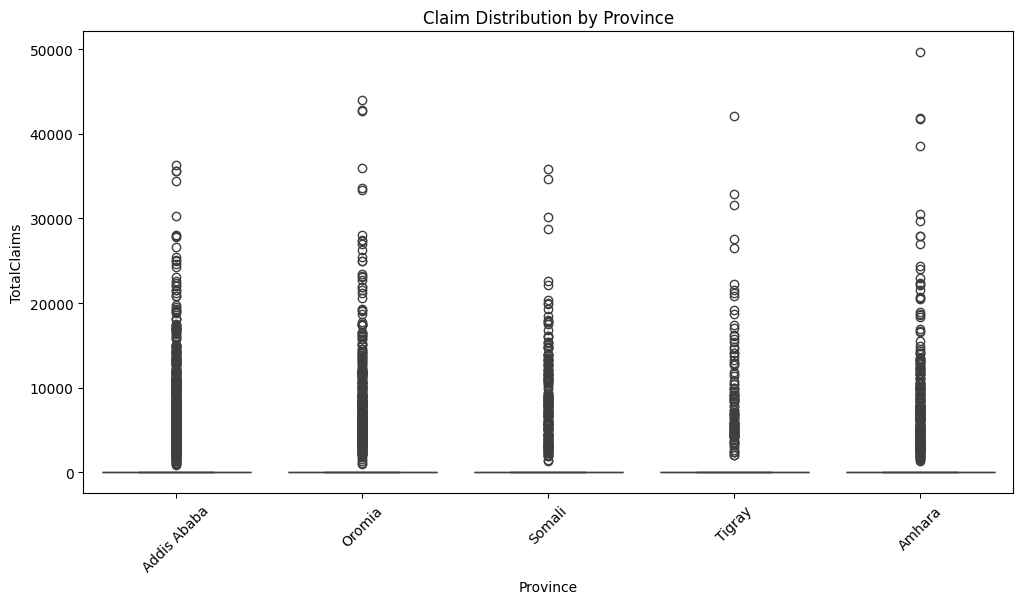

In [9]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Province",
    y="TotalClaims"
)

plt.xticks(rotation=45)

plt.title("Claim Distribution by Province")

plt.show()

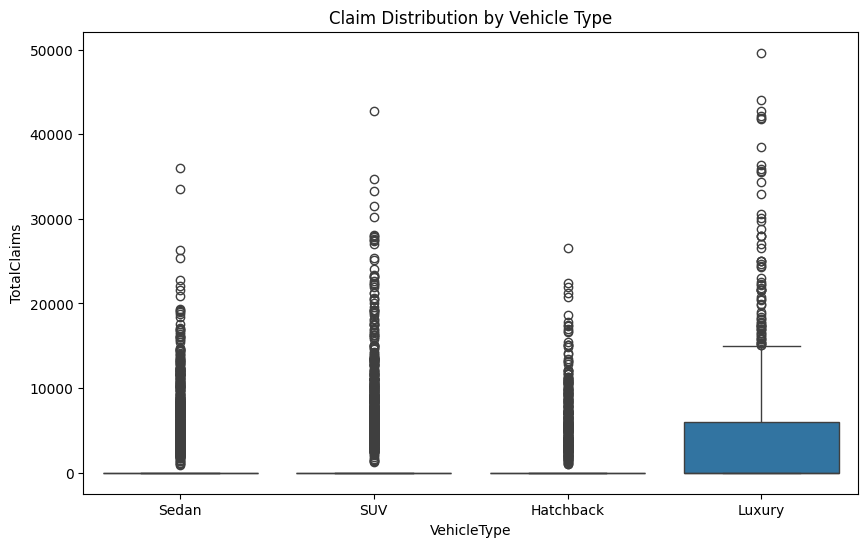

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="VehicleType",
    y="TotalClaims"
)

plt.title("Claim Distribution by Vehicle Type")

plt.show()

# Business Recommendations

- Provinces with significantly higher claims may require adjusted premium pricing.
- Certain vehicle types may represent higher insurance risk.
- Statistical testing supports data-driven insurance pricing strategies.